In [1]:
%pip install imagehash

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
     ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
     -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
     -- ------------------------------------- 0.3/4.2 MB ? eta -:--:--
     ---- ----------------------------------- 0.5/4.2 MB 728.2 kB/s eta 0:00:06
     ---- ----------------------------------- 0.5/4.2 MB 728.2 kB/s eta 0:00:06
     ------- -------------------------------- 0.8/4.2 MB 744.7 kB/s eta 0:00:05
     --------- ------------------------------ 1.0/4.2 MB 762.0 kB/s eta 0:00:05
     --------- ------------------------------ 1.0/4.2 MB 762.0 kB/s eta 0:00:05
     ------------ --------------------------- 1.3/4.2 MB 753.8 kB/s eta 0:00:04
     ------------ --------------------------- 1.3/4.2 MB 753.8 kB/s eta 0:00:04
     -------------- ------------------------- 1.6/4.2 MB 755.5 kB/s eta 0:00:04
     -----------

In [1]:
from PIL import Image
import imagehash
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import random
from watermarker.marker import add_mark

In [2]:
def compare(img_file1, img_file2, hash_func=imagehash.phash
            ):
    img1 = Image.open(img_file1)
    img2 = Image.open(img_file2)
#     print(f'size of img1: {img1.size}, size of img2: {img2.size}')
    img1_hash = hash_func(img1)
    img2_hash = hash_func(img2)
#     print(f'distance between img1 and img2: {img1_hash - img2_hash}')
    return img1_hash - img2_hash

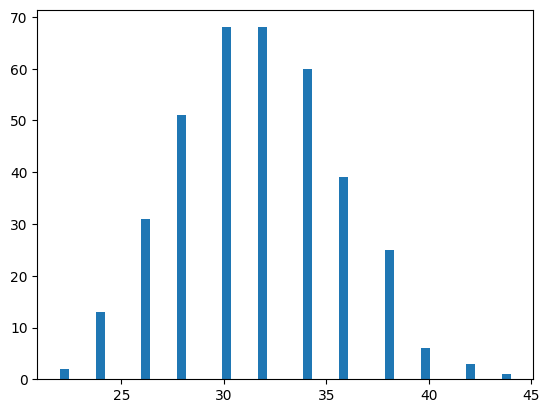

In [3]:
datasets_path = '../data/touhou'
datasets = os.listdir(datasets_path)
dataset1 = os.path.join(datasets_path, datasets[0])
images = os.listdir(dataset1)
images = [img for img in images if img.endswith('.png')]
img1 = Image.open(os.path.join(dataset1, images[0]))
img1_hash = imagehash.phash(img1)
distances = []
# 读取其中一张图片，计算与其它所有图片的哈希值距离，输出距离统计
for img_file in images[1:]:
    img = Image.open(os.path.join(dataset1, img_file))
    img_hash = imagehash.phash(img)
    distances.append(img1_hash - img_hash)
plt.hist(distances, bins=50)
plt.show()


In [ ]:
df = pd.DataFrame(distances, columns=['distance'])
df.describe()

,distance
count,367.000000
mean,31.634877
std,3.973640
min,22.000000
25%,28.000000
50%,32.000000
75%,34.000000
max,44.000000


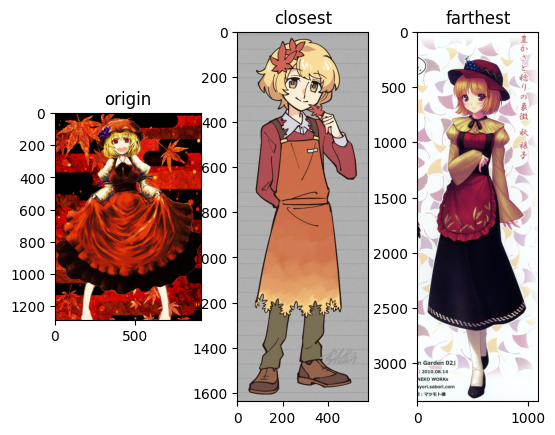

In [7]:
closest, farthest = df['distance'].idxmin(), df['distance'].idxmax()
# print(f'closest: {images[closest]}, farthest: {images[farthest]}')
plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('origin')
plt.subplot(1, 3, 2)
plt.imshow(Image.open(os.path.join(dataset1, images[closest])))
plt.title('closest')
plt.subplot(1, 3, 3)
plt.imshow(Image.open(os.path.join(dataset1, images[farthest])))
plt.title('farthest')
plt.show()

         distance
count  367.000000
mean    32.395095
std      5.161255
min     17.000000
25%     29.000000
50%     32.000000
75%     36.000000
max     45.000000


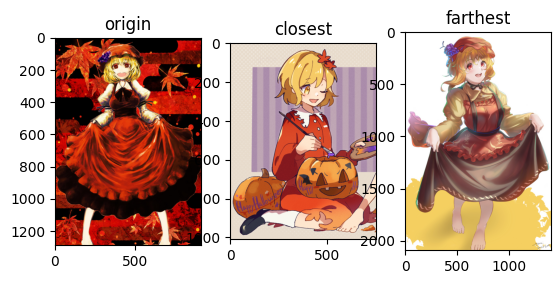

In [12]:
# 换用其它哈希函数
distances = []
img_file1 = os.path.join(dataset1, images[0])
for img_file in images[1:]:
    # img = Image.open(os.path.join(dataset1, img_file))
    img_file2 = os.path.join(dataset1, img_file)
    dis = compare(img_file1, img_file2, hash_func=imagehash.average_hash)
    distances.append(dis)
df_average = pd.DataFrame(distances, columns=['distance'])
print(df_average.describe())
closest, farthest = df_average['distance'].idxmin(), df_average['distance'].idxmax()
plt.subplot(1, 3, 1)
plt.imshow(img1)
plt.title('origin')
plt.subplot(1, 3, 2)
plt.imshow(Image.open(os.path.join(dataset1, images[closest])))
plt.title('closest')
plt.subplot(1, 3, 3)
plt.imshow(Image.open(os.path.join(dataset1, images[farthest])))
plt.title('farthest')
plt.show()

结论0：不同图片之间的哈希距离基本高于15

In [5]:
def compare_images(img1, img2, hash_func=imagehash.average_hash):
    return hash_func(img1) - hash_func(img2)

   0  1  2  3  4  5  6  7  8  9
0  1  0  0  0  0  1  0  0  1  0
1  1  0  0  0  0  1  0  0  1  0
2  1  0  0  0  0  1  0  1  1  0
3  1  0  1  0  0  1  0  0  1  0
4  1  0  0  0  0  1  0  0  1  0
5  1  0  0  0  0  1  0  0  1  0
6  1  0  1  0  0  1  0  0  1  0
7  1  0  0  0  0  1  0  0  1  0
8  1  0  0  0  0  1  0  0  1  0
9  1  0  0  0  0  1  0  0  1  0
          0     1          2     3     4     5     6          7     8     9
count  10.0  10.0  10.000000  10.0  10.0  10.0  10.0  10.000000  10.0  10.0
mean    1.0   0.0   0.200000   0.0   0.0   1.0   0.0   0.100000   1.0   0.0
std     0.0   0.0   0.421637   0.0   0.0   0.0   0.0   0.316228   0.0   0.0
min     1.0   0.0   0.000000   0.0   0.0   1.0   0.0   0.000000   1.0   0.0
25%     1.0   0.0   0.000000   0.0   0.0   1.0   0.0   0.000000   1.0   0.0
50%     1.0   0.0   0.000000   0.0   0.0   1.0   0.0   0.000000   1.0   0.0
75%     1.0   0.0   0.000000   0.0   0.0   1.0   0.0   0.000000   1.0   0.0
max     1.0   0.0   1.000000   0.0   0.0

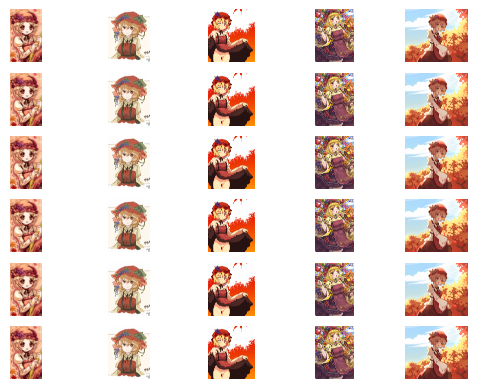

In [ ]:
# 取10张图，每张图添加一些噪声得到10份有噪声的图，计算与原图的哈希值距离，输出统计结果
def add_noise(img, noise_level=0.1):
    noise = np.random.normal(0, noise_level, img.size).reshape(img.shape)
    img = img + noise * 3
    img = np.clip(img, 0, 255)
    return img
testset = random.sample(images, 10)
distances = []
for i, img_file in enumerate(testset):
    img = Image.open(os.path.join(dataset1, img_file))
    if i < 5:
        plt.subplot(6, 5, i+1)
        plt.imshow(img)
        plt.axis('off')
    dists = []
    for j in range(10):
        img_noisy = add_noise(np.array(img), random.random())
        img_noisy = Image.fromarray(img_noisy.astype(np.uint8))
        dis = compare_images(img, img_noisy)
        dists.append(dis)
        if j < 5 and i < 5:
            plt.subplot(6, 5, 5 * (j  + 1) + i + 1)
            plt.imshow(img_noisy)
            plt.axis('off')
    distances.append(dists)
df_noisy = pd.DataFrame(distances).transpose()
print(df_noisy)
print(df_noisy.describe())
# plt.axis('off')
plt.show()



结论1：单纯加噪声，哈希值距离变化不大，说明哈希值对噪声不敏感

In [ ]:
# 对图片进行裁剪，计算与原图的哈希值距离，输出统计结果
def crop_image(img, crop_ratio=0.9):
    width, height = img.size
    new_width = int(width * crop_ratio)
    new_height = int(height * crop_ratio)
    left = (width - new_width) // 2
    top = (height - new_height) // 2
    right = left + new_width
    bottom = top + new_height
    return img.crop((left, top, right, bottom))
distances = []
# random.seed(time.time())
testset = random.sample(images, 10)
for i, img_file in enumerate(testset):
    img = Image.open(os.path.join(dataset1, img_file))
    dis = compare_images(img, crop_image(img))
    distances.append(dis)
df_cropped = pd.DataFrame(distances)
print(df_cropped)
print(df_cropped.describe())


    0
0   3
1   6
2   8
3  10
4   3
5   8
6   5
7   4
8  10
9   4
               0
count  10.000000
mean    6.100000
std     2.726414
min     3.000000
25%     4.000000
50%     5.500000
75%     8.000000
max    10.000000


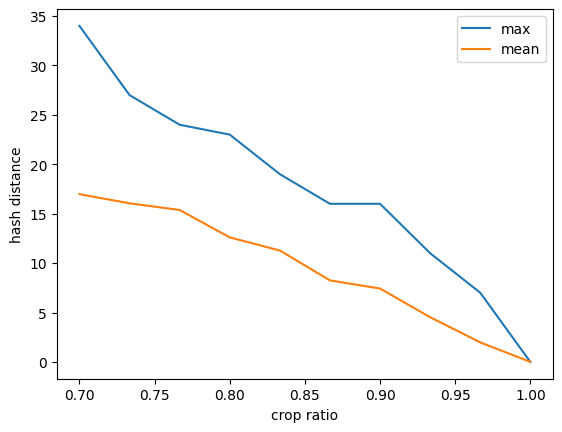

In [55]:
# 对于1.0到0.7的裁剪比例，计算与原图的哈希值距离，取最大值和平均值，分别拟合哈希距离和裁剪比例的关系
crop_ratios = np.linspace(1.0, 0.7, 10)
distances_max = []
distances_mean = []
for crop_ratio in crop_ratios:
    distances = []
    for img_file in random.sample(images, 40):
        img = Image.open(os.path.join(dataset1, img_file))
        dis = compare_images(img, crop_image(img, crop_ratio))
        distances.append(dis)
    distances_max.append(max(distances))
    distances_mean.append(np.mean(distances))
plt.plot(crop_ratios, distances_max, label='max')
plt.plot(crop_ratios, distances_mean, label='mean')
plt.xlabel('crop ratio')
plt.ylabel('hash distance')
plt.legend()
plt.show()


结论2：裁剪比例越大，哈希值距离越大，说明哈希值对裁剪敏感；但对于裁剪比例高于0.9时，哈希值距离仍低于15，说明裁剪后的图片仍能被识别为同一张图片

In [60]:
# 对图片进行有损压缩再解压，计算与原图的哈希值距离，输出统计结果
def compress_image(img: Image, quality):
    img.save('temp.jpg', 'JPEG', quality=quality)
    return Image.open('temp.jpg')
distances = []
testset = random.sample(images, 100)
for i, img_file in enumerate(testset):
    img = Image.open(os.path.join(dataset1, img_file))
    dis = compare_images(img, compress_image(img, 1))
    distances.append(dis)
df_compressed = pd.DataFrame(distances)
print(df_compressed)
print(df_compressed.describe())

    0
0   0
1   2
2   0
3   2
4   0
.. ..
95  0
96  0
97  2
98  1
99  2

[100 rows x 1 columns]
                0
count  100.000000
mean     0.920000
std      1.031621
min      0.000000
25%      0.000000
50%      1.000000
75%      1.000000
max      5.000000


结论3：有损压缩几乎不影响哈希值距离

In [ ]:
%pip install filestools

In [8]:
# 在图片上添加随机水印，计算与原图的哈希值距离，输出统计结果
def add_watermark(img_file, watermark):
    add_mark(img_file,mark=watermark, out='watermarked', opacity=0.5, angle=45, space=30)
distances = []
testset = random.sample(images, 50)
watermark = 'touhou'
for i, img_file in enumerate(testset):
    img = Image.open(os.path.join(dataset1, img_file))
    add_watermark(os.path.join(dataset1, img_file), watermark)
    dis = compare_images(img, Image.open('watermarked/'+img_file))
    # dis = compare_images(img, add_watermark(img, watermark))    
    distances.append(dis)

df_watermarked = pd.DataFrame(distances)
print(df_watermarked)
print(df_watermarked.describe())

watermarked\b699a058ab507b60cc3a2a80d416f85a6a0e069b.png 保存成功。
watermarked\9999bb7ab51deff390658c5e0cfd423a54686695.png 保存成功。
watermarked\3df93f1ef11cae34674298eaad17e5b3e9969f46.png 保存成功。
watermarked\69172693dae3c60f9def4e2b94ade1d4c6568260.png 保存成功。
watermarked\00eedf814d64be55befe647fefcb17c0bfd44777.png 保存成功。
watermarked\364d1f5c72e55e2eace5ee1f92ebb77c1721b00a.png 保存成功。
watermarked\dfde9fa294432fbd435d25749f1561fd59c33601.png 保存成功。
watermarked\f914ec346ba9ad0f59c3013b977c1fc4841cd525.png 保存成功。
watermarked\59aef683ea637b8cd6ea80b0bf1c5fab4de469ee.png 保存成功。
watermarked\c4946fc2731e45320a639f92ab9f0f5499c92744.png 保存成功。
watermarked\3b89722ff3876cfe92e5d80e23a33991323f3936.png 保存成功。
watermarked\f13422bd781b3e4eb980c43e6e38554ae3ae1aa1.png 保存成功。
watermarked\a9e6668ae886b86bf89d93058bb700a812bd3f0d.png 保存成功。
watermarked\e64c91c39f4361a60d102c02583501be0955785a.png 保存成功。
watermarked\5e83655d7c6d9369b3774ea8bfcb7ff1b325e078.png 保存成功。
watermarked\cad2cf19cd12cf435f608c1b3f979530a79cab4b.pn

In [9]:
# 读取已添加水印的图片，使用phash，计算与原图的哈希值距离，输出统计结果
distances = []
for i, img_file in enumerate(testset):
    img = Image.open(os.path.join(dataset1, img_file))
    dis = compare_images(img, Image.open('watermarked/'+img_file), imagehash.phash)
    distances.append(dis)

df_watermarked = pd.DataFrame(distances)
print(df_watermarked)
print(df_watermarked.describe())

    0
0   0
1   0
2   2
3   2
4   2
5   0
6   2
7   0
8   2
9   0
10  4
11  0
12  0
13  0
14  2
15  0
16  2
17  0
18  2
19  2
20  0
21  0
22  0
23  2
24  0
25  2
26  2
27  0
28  2
29  0
30  0
31  2
32  0
33  0
34  2
35  0
36  0
37  4
38  0
39  2
40  0
41  0
42  0
43  2
44  2
45  2
46  2
47  2
48  0
49  0
               0
count  50.000000
mean    1.000000
std     1.160577
min     0.000000
25%     0.000000
50%     0.000000
75%     2.000000
max     4.000000


结论4：水印对哈希值距离几乎没有影响（使用average_hash或phash函数计算哈希值距离）